# Baseline: Random Forest

> Objetivo: treinar um modelo simples de random forest e avaliar desempenho no conjunto de teste.

> Referência: conteúdo copiado e adaptado de Modelação.ipynb.

## 1) Importação e leitura dos dados

In [1]:
# importações de bibliotecas
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

## 2) Preparação dos dados

In [2]:
# Converter variáveis categóricas e definir X/y
ortho_clean['Grupo_pre'] = ortho_clean['Grupo_pre'].astype('category')
ortho_clean['Sexo'] = ortho_clean['Sexo'].astype('category')

X = ortho_clean.drop('mudanca_CPAK', axis=1)
y = ortho_clean['mudanca_CPAK']

X_ohe = pd.get_dummies(X, columns=['Grupo_pre', 'Sexo'], drop_first=True)

# Split estratificado dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

## 3) Treino do modelo (Random Forest)

In [3]:
# Treino do baseline com Random Forest
clf_RF = RandomForestClassifier(random_state=42)
clf_RF = clf_RF.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_RF = clf_RF.predict(X_test)
print(y_pred_RF)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0]


## 4) Avaliação do modelo

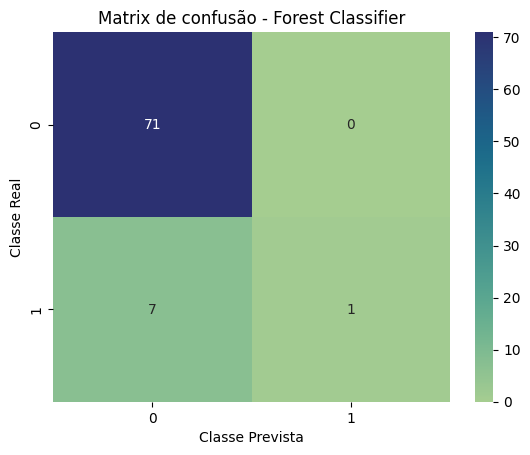

In [4]:
# matriz de confusão
confusion_matrix_RF = confusion_matrix(y_test, y_pred_RF)

#gráfico de matriz de confusão
sns.heatmap(confusion_matrix_RF, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matrix de confusão - Forest Classifier")
plt.show()

In [5]:
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        71
           1       1.00      0.12      0.22         8

    accuracy                           0.91        79
   macro avg       0.96      0.56      0.59        79
weighted avg       0.92      0.91      0.88        79



In [6]:
#Area Under the Curve (AUC)
auc = roc_auc_score(y_test, y_pred_RF)
print("AUC:", auc)

AUC: 0.5625


In [7]:
# Cross Validation: K-fold
pred_cross_RF = cross_val_predict(clf_RF, X, y)

print(classification_report(y, pred_cross_RF, digits=4))



              precision    recall  f1-score   support

           0     0.9105    0.9915    0.9493       236
           1     0.6000    0.1154    0.1935        26

    accuracy                         0.9046       262
   macro avg     0.7553    0.5535    0.5714       262
weighted avg     0.8797    0.9046    0.8743       262



## 5) Melhoria prática da Random Forest (bloco curto)

Estudo no cenário pedido:
1. Retirar IMC, Peso e Altura_cm.
2. Retirar WT_0 e componentes (WD_0, WR_0, WAtotal_0/WATotal).
3. Aplicar OHE + tuning simples e avaliar com StratifiedKFold.

In [15]:
# Ponto 5: melhoria prática e curta para RF (sem IMC/Peso/Altura e sem WT_0/componentes)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_auc_score

X_melhoria_rf = ortho_clean.drop('mudanca_CPAK', axis=1).copy()
y_melhoria_rf = ortho_clean['mudanca_CPAK']

# Remover variáveis pedidas
mapa_rf = {c.lower(): c for c in X_melhoria_rf.columns}
chave_wa_rf = 'watotal_0' if 'watotal_0' in mapa_rf else ('watotal' if 'watotal' in mapa_rf else None)
remover_rf = [mapa_rf[c] for c in ['imc', 'peso', 'altura_cm', 'wt_0', 'wd_0', 'wr_0'] if c in mapa_rf]
if chave_wa_rf is not None:
    remover_rf.append(mapa_rf[chave_wa_rf])
X_melhoria_rf = X_melhoria_rf.drop(columns=remover_rf, errors='ignore')

# OHE apenas para colunas categóricas
cols_cat_rf = [c for c in X_melhoria_rf.columns if X_melhoria_rf[c].dtype == 'object' or str(X_melhoria_rf[c].dtype) == 'category']
cols_num_rf = [c for c in X_melhoria_rf.columns if c not in cols_cat_rf]

prep_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', cols_num_rf),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cols_cat_rf)
    ]
)

pipe_rf = Pipeline([
    ('prep', prep_rf),
    ('modelo', RandomForestClassifier(random_state=42, class_weight='balanced_subsample'))
] )

param_rf = {
    'modelo__n_estimators': [200, 400],
    'modelo__max_depth': [None, 8, 14],
    'modelo__min_samples_leaf': [1, 3]
}

cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(pipe_rf, param_rf, scoring='recall_macro', cv=cv_rf, n_jobs=-1)
grid_rf.fit(X_melhoria_rf, y_melhoria_rf)

print('Variáveis removidas:', remover_rf)
print('Melhores parâmetros RF:', grid_rf.best_params_)
print('Melhor Recall_macro (CV):', round(grid_rf.best_score_, 4))

pred_rf = cross_val_predict(grid_rf.best_estimator_, X_melhoria_rf, y_melhoria_rf, cv=cv_rf)
proba_rf = cross_val_predict(grid_rf.best_estimator_, X_melhoria_rf, y_melhoria_rf, cv=cv_rf, method='predict_proba')
print('\n=== Classification report (RF melhorada) ===')
print(classification_report(y_melhoria_rf, pred_rf, digits=4))

precision_macro = precision_score(y_melhoria_rf, pred_rf, average='macro', zero_division=0)
recall_macro = recall_score(y_melhoria_rf, pred_rf, average='macro', zero_division=0)
f1_macro = f1_score(y_melhoria_rf, pred_rf, average='macro', zero_division=0)

try:
    auc_roc = roc_auc_score(y_melhoria_rf, proba_rf[:, 1])
except Exception:
    auc_roc = float('nan')

resumo_rf = pd.DataFrame([
    ['RF melhorada (sem IMC/Peso/Altura + sem WT_0/componentes)', precision_macro, recall_macro, f1_macro, auc_roc]
] , columns=['Cenario', 'Precision_macro', 'Recall_macro', 'F1_macro', 'AUC_ROC'])
print('\nMétricas principais: Precision e Recall')
print('Métricas secundárias: F1 e AUC-ROC')
print(resumo_rf)

Variáveis removidas: ['IMC', 'Peso', 'Altura_cm', 'WT_0', 'WD_0', 'WR_0', 'WAtotal_0']
Melhores parâmetros RF: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 3, 'modelo__n_estimators': 400}
Melhor Recall_macro (CV): 0.5659

=== Classification report (RF melhorada) ===
              precision    recall  f1-score   support

           0     0.9139    0.9449    0.9292       236
           1     0.2778    0.1923    0.2273        26

    accuracy                         0.8702       262
   macro avg     0.5959    0.5686    0.5782       262
weighted avg     0.8508    0.8702    0.8595       262


Métricas principais: Precision e Recall
Métricas secundárias: F1 e AUC-ROC
                                             Cenario  Precision_macro  \
0  RF melhorada (sem IMC/Peso/Altura + sem WT_0/c...         0.595856   

   Recall_macro  F1_macro   AUC_ROC  
0      0.568611   0.57822  0.794817  


## 6) [BLOCO OPCIONAL - PODE APAGAR] Estudo complementar (referência: Modelação.ipynb)

### INICIO DO BLOCO OPCIONAL
Apaga desde a próxima célula até à célula de "FIM DO BLOCO OPCIONAL" se quiseres remover esta parte.

Nesta secção vamos:
1. Comparar o efeito de one-hot encoding em Grupo_pre e Sexo.
2. Verificar se o SMOTE melhora as métricas.
3. Estudar redundância entre variáveis compostas (IMC e WT_0).

In [ ]:
# [BLOCO OPCIONAL - PODE APAGAR] Preparação do estudo (simples)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    smote_disponivel = True
except Exception:
    smote_disponivel = False

# Dados base
y_estudo = ortho_clean['mudanca_CPAK']
X_estudo = ortho_clean.drop('mudanca_CPAK', axis=1).copy()

# Colunas categóricas que queremos testar
mapa_cols = {c.lower(): c for c in X_estudo.columns}
cols_cat = [mapa_cols[c] for c in ['grupo_pre', 'sexo'] if c in mapa_cols]

# Mudança A: sem OHE (usar códigos)
X_sem_ohe = X_estudo.copy()
for c in cols_cat:
    X_sem_ohe[c] = X_sem_ohe[c].astype('category').cat.codes

# Mudança B: com OHE
X_com_ohe = pd.get_dummies(X_estudo, columns=cols_cat, drop_first=True)

# CV fixa para comparação justa
cv_estudo = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
modelo_estudo = RandomForestClassifier(random_state=42)

In [ ]:
# [BLOCO OPCIONAL - PODE APAGAR] Mudança -> métricas

# Mudança A: Sem OHE
pred_sem_ohe = cross_val_predict(modelo_estudo, X_sem_ohe, y_estudo, cv=cv_estudo)
print('=== Sem OHE ===')
print(classification_report(y_estudo, pred_sem_ohe, digits=4))

# Mudança B: Com OHE
pred_com_ohe = cross_val_predict(modelo_estudo, X_com_ohe, y_estudo, cv=cv_estudo)
print('=== Com OHE (Grupo_pre + Sexo) ===')
print(classification_report(y_estudo, pred_com_ohe, digits=4))

resultados = [
    ['Sem OHE', f1_score(y_estudo, pred_sem_ohe, average='macro'), balanced_accuracy_score(y_estudo, pred_sem_ohe)],
    ['Com OHE (Grupo_pre + Sexo)', f1_score(y_estudo, pred_com_ohe, average='macro'), balanced_accuracy_score(y_estudo, pred_com_ohe)]
]

# Mudança C: Com OHE + SMOTE
if smote_disponivel:
    pipeline_smote = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('modelo', RandomForestClassifier(random_state=42))
    ])
    pred_com_smote = cross_val_predict(pipeline_smote, X_com_ohe, y_estudo, cv=cv_estudo)
    print('=== Com OHE + SMOTE ===')
    print(classification_report(y_estudo, pred_com_smote, digits=4))

    resultados.append([
        'Com OHE + SMOTE',
        f1_score(y_estudo, pred_com_smote, average='macro'),
        balanced_accuracy_score(y_estudo, pred_com_smote)
    ])
else:
    print('SMOTE indisponível para este teste.')

resultado_modelo = pd.DataFrame(resultados, columns=['Cenario', 'F1_macro', 'Balanced_Accuracy'])
print(resultado_modelo)
print('Melhor cenário pelo F1_macro:', resultado_modelo.sort_values('F1_macro', ascending=False).iloc[0]['Cenario'])

=== Classification Report: Sem OHE ===
              precision    recall  f1-score   support

           0     0.9073    0.9958    0.9495       236
           1     0.6667    0.0769    0.1379        26

    accuracy                         0.9046       262
   macro avg     0.7870    0.5363    0.5437       262
weighted avg     0.8835    0.9046    0.8690       262

=== Classification Report: Com OHE (Grupo_pre + Sexo) ===
              precision    recall  f1-score   support

           0     0.9035    0.9915    0.9455       236
           1     0.3333    0.0385    0.0690        26

    accuracy                         0.8969       262
   macro avg     0.6184    0.5150    0.5072       262
weighted avg     0.8469    0.8969    0.8585       262

=== Classification Report: Com OHE + SMOTE ===
              precision    recall  f1-score   support

           0     0.9073    0.9534    0.9298       236
           1     0.2143    0.1154    0.1500        26

    accuracy                         0

In [ ]:
# [BLOCO OPCIONAL - PODE APAGAR] Redundância: composição -> métricas
import numpy as np

mapa = {c.lower(): c for c in ortho_clean.columns}

# Mudança: IMC como função de Peso e Altura_cm
if all(k in mapa for k in ['imc', 'peso', 'altura_cm']):
    imc_real = ortho_clean[mapa['imc']]
    imc_calc = ortho_clean[mapa['peso']] / ((ortho_clean[mapa['altura_cm']] / 100.0) ** 2)
    erro = (imc_real - imc_calc).abs()
    corr = np.corrcoef(imc_real, imc_calc)[0, 1]

    print('=== IMC vs (Peso, Altura_cm) ===')
    print('Correlação:', round(corr, 6))
    print('Erro médio absoluto:', round(erro.mean(), 6))
    print('Erro máximo absoluto:', round(erro.max(), 6))
else:
    print('Faltam colunas para IMC:', [k for k in ['imc', 'peso', 'altura_cm'] if k not in mapa])

# Mudança: WT_0 como função de WD_0, WR_0 e WAtotal_0 (ou WATotal)
chave_wa = 'watotal_0' if 'watotal_0' in mapa else ('watotal' if 'watotal' in mapa else None)
if all(k in mapa for k in ['wt_0', 'wd_0', 'wr_0']) and chave_wa is not None:
    wt_real = ortho_clean[mapa['wt_0']]
    wt_calc = ortho_clean[mapa['wd_0']] + ortho_clean[mapa['wr_0']] + ortho_clean[mapa[chave_wa]]
    erro = (wt_real - wt_calc).abs()
    corr = np.corrcoef(wt_real, wt_calc)[0, 1]

    print(f'=== WT_0 vs (WD_0, WR_0, {mapa[chave_wa]}) ===')
    print('Correlação:', round(corr, 6))
    print('Erro médio absoluto:', round(erro.mean(), 6))
    print('Erro máximo absoluto:', round(erro.max(), 6))
else:
    print('Faltam colunas para WT_0:', [k for k in ['wt_0', 'wd_0', 'wr_0', 'watotal_0/watotal'] if (k != 'watotal_0/watotal' and k not in mapa) or (k == 'watotal_0/watotal' and chave_wa is None)])

print('\nLeitura rápida: correlação alta e erro baixo => variável potencialmente redundante.')

--- Redundância IMC ---
Correlação IMC vs IMC_recalculado: 1.0
Erro absoluto médio: 0.0
Erro absoluto máximo: 0.0
Colunas em falta para WT_0: ['WATotal']

Interpretação rápida: correlação muito alta e erro baixo sugerem forte redundância.


### FIM DO BLOCO OPCIONAL

Se quiseres apagar este estudo, remove desde o "INICIO DO BLOCO OPCIONAL" até esta célula.